# Group 1 Project Notebook

## Problem definition and objectives

The purpose of our project is to understand the relationship between crime in English regions and their index of multiple deprivation. Our hypothesis is that areas with higher levels of deprivation (the closer to 1 they are ranked the more deprived they are) are more likely to experience higher levels of crime.

The IMD data comes out every four - five years so by completing our analysis and then building a machine learning model which predicts the IMD score for an ITL2 region, based on the level of crime it has experienced that year we aim to provide annual estimates for local (ITL2 regions) areas based on our model.

This matters for both the police and local authorities will be ab

## Importing Packages

In [20]:
import pandas as pd
import numpy as np
import statistics 
import openpyxl #Make sure to also have this downloaded so that excel can be read
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import os

## Data Cleaning and Preprocessing

- Crime
    Key Tasks:
    - Focus on the 2025 data
    - Group by location (ITl1 regions and ITl2 regions)
    - Remove Wales data
    - Remove national police forces / create a new data field for that
- Index of Multiple Deprivation
- Wellness Data

#### Crime cleaning

Below is the process we undertook to clean the crime data as well as a few notes.

In [ ]:
# Uploading the crime data
df_2025 = pd.read_excel("old_data\old_historical_crime_data.xlsx",
              sheet_name="2024_25",
              index_col=0)

print(df_2025.info())

# Checking for missing values, with none found across all columns
missing_values = df_2025.isnull().sum()
print(f'Total missing values for the Index of Multiple Deprivation \
(IMD) dataset: {missing_values.sum()}')

#Investigating if there are any outliers, although we decided to include all offences for the relevant regions.
data = df_2025.loc[:,"Number of Offences"]

def find_outliers_iqr(data):
    """" The purpose of this function is to detect whether or not there are outliers within the crime data, particularly around the number of offences."""
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data < lower_bound) | (data >
    upper_bound)]
    return f"Here are the outliers: {outliers}, the lower bound: {lower_bound} and the upper bounds {upper_bound}."

find_outliers_iqr(data)




# Investigating data types and assessing if they are the most appropriate for the values
print(f'\nAll data types for the Crime dataset: \nFinancial Quarter: {df_2025['Financial Quarter'].dtypes}\
\nForce Name: {df_2025['Force Name'].dtypes}\nOffence Description: {df_2025['Offence Description'].dtypes}\
\nOffence Group: {df_2025['Offence Group'].dtypes}\nOffence Subgroup: \
{df_2025['Offence Subgroup'].dtypes}\
\nOffence Code: {df_2025['Offence Code'].dtypes}\nNumber of Offences: {df_2025['Number of Offences'].dtypes}')

# Here I am working out which are the unique locations so I can map to the ITL1 and ITL2 regions
df_copy = df_2025.copy()
df_copy.duplicated(subset='Force Name')
df_copy.duplicated(subset='Force Name').sum()
df_copy.drop_duplicates(subset='Force Name', inplace=True) # Want to know all of the unique force names so that I can find out which regions they belong to
print(df_copy["Force Name"]) # Prints all Police names so I can find out which region they're in. I did this through a manual search using this website - https://www.ons.gov.uk/methodology/geography/ukgeographies/eurostat

# Need to clean the data from Force Name
ITL_1_matches = { # Note I don't have any Scotland or Northern Ireland data due to the various devolved powers. I have mapped the Welsh and national english forces but will remove these at a later stage, so that a deep dive of english regional data only can be done.
    "Avon and Somerset": "South West (England)",
    "Bedfordshire": "East (England)",
    "British Transport Police": "UK",
    "Cambridgeshire": "East (England)",
    "Cheshire": "North West (England)",
    "Cleveland": "North East (England)",
    "Cumbria": "North West (England)",
    "Derbyshire": "East Midlands",
    "Devon and Cornwall": "South West (England)",
    "Dorset": "South West (England)",
    "Durham": "North East (England)",
    "Dyfed-Powys": "Wales",
    "Essex": "East (England)",
    "Gloucestershire": "South West (England)",
    "Greater Manchester": "North West (England)",
    "Gwent": "Wales",
    "Hampshire": "South East (England)",
    "Hertfordshire": "East (England)",
    "Humberside": "Yorkshire and The Humber",
    "Kent": "South East (England)",
    "Lancashire": "North West (England)",
    "Leicestershire": "East Midlands",
    "Lincolnshire": "East Midlands",
    "London, City of": "London",
    "Merseyside": "North West (England)",
    "Metropolitan Police": "London",
    "Norfolk": "East (England)",
    "North Wales": "Wales",
    "North Yorkshire": "Yorkshire and The Humber",
    "Northamptonshire": "East Midlands",
    "Northumbria": "North East (England)",
    "Nottinghamshire": "East Midlands",
    "South Wales": "Wales",
    "South Yorkshire": "Yorkshire and The Humber",
    "Staffordshire": "West Midlands",
    "Suffolk": "East (England)",
    "Surrey": "South West (England)",
    "Sussex": "South East (England)",
    "Thames Valley": "South East (England)",
    "Warwickshire": "West Midlands",
    "West Midlands": "West Midlands",
    "West Mercia": "West Midlands",
    "West Yorkshire": "Yorkshire and The Humber",
    "Wiltshire": "South West (England)",
    "Action Fraud": "UK",
    "CIFAS": "UK",
    "UK Finance": "UK"
    }

df_2025["ITL1 region"] = df_2025["Force Name"].map(ITL_1_matches) # Mapping regions to the various police forces


print(df_2025["ITL1 region"].isnull().sum()) # To test every police force has been mapped to make sure there are no null values
print(df_2025["ITL1 region"].info()) # To test every police force has been mapped by counting the number of rows in this column vs the document


# Our other data doesn't have Wales in it and as there is no Scotland or Northern Irish data it is best to stick to England. Therefore I have deleted Wales from the dataset

updated_df = df_2025.copy() #Making a copy which is where I remove a lot of unnecessary data (e.g. Wales and national police forces)

welsh_forces = updated_df[updated_df["ITL1 region"] == "Wales"] # Filtering to only include Wales forces

# Can be removed but an example of filtering data to only Welsh forces
welsh_forces.drop_duplicates(subset='ITL1 region', inplace=True) # Removing all with Wales
welsh_forces.reset_index(inplace=True) # Setting the index to numbers so its easy to remove
welsh_forces.drop(0, inplace=True) # Now I have no welsh forces in this filter
# updated_df.info()


updated_df.loc[updated_df["ITL1 region"] == "Wales", "ITL1 region"] = None # Making this null values so I can remove the data
updated_df.dropna(inplace=True) # Removing Welsh data
print(updated_df.info()) # Checking to make sure it has been removed

# Adding in ITL2 information

ITL_2_matches = {
    "Avon and Somerset": ["West of England", "North Somerset, Somerset and Dorset"],
    "Bedfordshire": ["Bedfordshire and Hertfordshire"],
    "British Transport Police": ["UK"],
    "Cambridgeshire": ["Cambridgeshire and Peterborough"],
    "Cheshire": ["Cheshire"],
    "Cleveland": ["Tees Valley"],
    "Cumbria": ["Cumbria"],
    "Derbyshire": ["Derbyshire and Nottinghamshire"],
    "Devon and Cornwall": ["Devon", "Cornwall and Isles of Scilly"],
    "Dorset": ["North Somerset, Somerset and Dorset"],
    "Durham": ["Northumberland, Durham and Tyne & Wear"],
    "Dyfed-Powys": ["Mid and South West Wales"],
    "Essex": ["Essex"],
    "Gloucestershire": ["Gloucestershire and Wiltshire"],
    "Greater Manchester": ["Greater Manchester"],
    "Gwent": ["South East Wales"],
    "Hampshire": ["Hampshire and Isle of Wight"],
    "Hertfordshire": ["Bedfordshire and Hertfordshire"],
    "Humberside": ["East Yorkshire and Northern Lincolnshire"],
    "Kent": ["Kent"],
    "Lancashire": ["Lancashire"],
    "Leicestershire": ["Leicestershire, Rutland and Northamptonshire"],
    "Lincolnshire": ["Lincolnshire"],
    "London, City of": ["Inner London - West"],
    "Merseyside": ["Merseyside"],
    "Metropolitan Police": ["Inner London - West", "Inner London - East", "Outer London - East and North East", "Outer London - South", "Outer London - West and North West"],
    "Norfolk": ["Norfolk"],
    "North Wales": ["North Wales"],
    "North Yorkshire": ["North Yorkshire"],
    "Northamptonshire": ["Leicestershire, Rutland and Northamptonshire"],
    "Northumbria": ["Northumberland, Durham and Tyne & Wear"],
    "Nottinghamshire": ["Derbyshire and Nottinghamshire"],
    "South Wales": ["South East Wales", "Mid and South West Wales"],
    "South Yorkshire": ["South Yorkshire"],
    "Staffordshire": ["Shropshire and Staffordshire"],
    "Suffolk": ["Suffolk"],
    "Surrey": ["Surrey, East and West Sussex"],
    "Sussex": ["Surrey, East and West Sussex"],
    "Thames Valley": ["Berkshire, Buckinghamshire and Oxfordshire"],
    "Warwickshire": ["Herefordshire, Worcestershire and Warwickshire"],
    "West Mercia": ["Shropshire and Staffordshire", "Herefordshire, Worcestershire and Warwickshire"],
    "West Midlands": ["West Midlands"],
    "West Yorkshire": ["West Yorkshire"],
    "Wiltshire": ["Gloucestershire and Wiltshire"],
    "Action Fraud": ["UK"],
    "CIFAS": ["UK"],
    "UK Finance": ["UK"],
}

updated_df["ITL2 region"] = updated_df["Force Name"].map(ITL_2_matches) # Mapping the ITL2 regions if we would like them
# print(updated_df.head(3)) # Checking to make sure it ran correctly
print(updated_df.info())


national_forces = updated_df[updated_df["ITL1 region"] == "UK"]
national_forces.reset_index(inplace=True)
national_forces.to_csv("extra_materials\CLEANED-national_forces_crime_data_2024-2025.csv") # Creating new data set

print(updated_df.info())
# Removing from regional data set
updated_df.loc[updated_df["ITL1 region"] == "UK", "ITL1 region"] = None # Making this null values so I can remove the data
updated_df.dropna(inplace=True) # Removing UK data
print(updated_df.info()) # Checking to make sure it has removed
print(updated_df[updated_df["ITL1 region"] == "UK"]) # DOuble checking there are no more of these rows

updated_df.reset_index(inplace=True) # Creating an index which is numbers based
updated_df.to_csv("CLEANED-regional_forces_crime_data_2024-2025.csv") # Saving the cleaned data



Financial Year
2024/25           Avon and Somerset
2024/25                Bedfordshire
2024/25    British Transport Police
2024/25              Cambridgeshire
2024/25                    Cheshire
2024/25                   Cleveland
2024/25                     Cumbria
2024/25                  Derbyshire
2024/25          Devon and Cornwall
2024/25                      Dorset
2024/25                      Durham
2024/25                 Dyfed-Powys
2024/25                       Essex
2024/25             Gloucestershire
2024/25          Greater Manchester
2024/25                       Gwent
2024/25                   Hampshire
2024/25               Hertfordshire
2024/25                  Humberside
2024/25                        Kent
2024/25                  Lancashire
2024/25              Leicestershire
2024/25                Lincolnshire
2024/25             London, City of
2024/25                  Merseyside
2024/25         Metropolitan Police
2024/25                     Norfolk
2024/25      

#### Crime Data Cleaning Reasoning
- Outliers: The outliers identified were identified through the locations they were grouped in rather than the 


- Deleting columns: 





#### IMD cleaning

Below is the process we undertook to clean the IMD data, as well as notes to explain why we did this:
- Investigated data (type of data, missing values)
- Removed any unneccessary columns
- Mapped LAD codes to ITLs

The ITL1 and ITL2 regions can then be utilised across the datasets for this project, ensuring that location data is directly comparable. This is necessary as, for example, the police dataset utilises police districts that are not directly comparable to LSOAs or LADs.

##### A note on the data:
The Index of Multiple Deprivation (IMD) dataset was published by the Ministry of Housing, Communities & Local Government (MHCLG) and was constructed by Oxford Consultants for Social Inclusion (OCSI) and Deprivation.org. This dataset was downloaded from the GOV.UK website, as an Excel file (.xlsx), using the link 'https://www.gov.uk/government/statistics/english-indices-of-deprivation-2025' on 9th June 2026. The official statistics on the source website were published on 30 October 2025 and last updated on 17 November 2025.

An additional dataset has also been utilised, to support the preprocessing of the IMD dataset, the necessity of which is detailed fully later in this notebook. In brief, the dataset is required for standardising the location data of the IMD dataset, to allow comparison to other datasets (such as the ‘Police recorded crime open data tables, year ending March 2013 onwards’ dataset) and improve overall ease of understanding.

The 'Local Authority District (December 2024) to LAU1 to ITL3 to ITL2 to ITL1 (January 2025) Lookup in the UK' dataset was published by the Office for National Statistics (ONS). The dataset was downloaded from the National Data Library website, as a csv file (.csv), using the link 'https://www.data.gov.uk/dataset/2b47adcc-62b6-4dd3-a6cb-271b3035e9fd/local-authority-district-december-2024-to-lau1-to-itl3-to-itl2-to-itl1-january-2025-lookup-in-t' on 9th June 2026. The dataset was last updated on 09 December 2025 and the csv file was added to the website on 12 January 2025. 

In [ ]:

# Uploading the IMD dataset
df = pd.read_excel('old_data\old_2025_index_of_multiple_deprivation.xlsx',
                  sheet_name='IMD25')

# Visually checking the first and last 5 rows of data in the IMD dataset
# Including key information, such as total number of rows, column names and a sample of data
print(f'First five rows of data:\n{df.head(5)}')
print(f'\nLast five rows of data:\n{df.tail(5)}')

# Shape of dataset - to confirm the number of rows and columns
print(f'\nPre-cleaning IMD dataset shape: {df.shape}')

# Summary statistics pre-cleaning
# Notice that this only provides stats for numerical data (the IMD rank and IMD decile)
print(f'\nPre-cleaning IMD summary statistics:\n{df.describe()}')

# Copying the IMD dataset, in order to preserve the original dataset
df_copy = df.copy()

# Checking for missing values, with none found across all columns
missing_values = df_copy.isnull().sum()
print(f'Total missing values for the Index of Multiple Deprivation \
(IMD) dataset: {missing_values.sum()}')

# Investigating data types and assessing if they are the most appropriate for the values ()
print(f'\nAll data types for the IMD dataset: \nLSOA Code: {df_copy['LSOA code (2021)'].dtypes}\
\nLSOA Name: {df_copy['LSOA name (2021)'].dtypes}\nLAD Code: {df_copy['Local Authority District code (2024)'].dtypes}\
\nLAD Name: {df_copy['Local Authority District name (2024)'].dtypes}\nIMD Rank: \
{df_copy['Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)'].dtypes}\
\nIMD Decile: {df_copy['Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA'].dtypes}')

# Checking that the IMD rank is between 1 and 33755, and that the IMD decile is between 1 and 10
if df_copy[(df_copy['Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)'] < 1) | \
    (df_copy['Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)']> 33755)].shape[0]:
    print(f'\nUnexpected IMD Rank values:\n{df_copy[(df_copy['Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)']\
    < 1) | (df_copy['Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)']> 33755)].values}')
else:
    print('\nNo unexpected IMD Rank values.')

if df_copy[(df_copy['Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA'] < 1) | \
    (df_copy['Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA']> 10)].shape[0]:
    print(f'\nUnexpected IMD Decile values:\n{df_copy[(df_copy['Index of Multiple Deprivation (IMD) \
    Decile (where 1 is most deprived 10% of LSOA'] < 1) | (df_copy['Index of Multiple Deprivation (IMD) Decile \
    (where 1 is most deprived 10% of LSOA']> 10)].values}')
else:
    print('\nNo unexpected IMD Decile values.')

# Remove unnecessary columns, such as the LSOA code, LSOA name and LAD name because they're unnecessary
df_imd = df.drop(['LSOA code (2021)', 'LSOA name (2021)', \
                  'Local Authority District name (2024)'], axis=1)

# Shape of dataset - to confirm the columns have been deleted successfully
print(f'IMD dataset shape: {df_imd.shape}')

# Check for duplicates
# This can be done using the IMD rank, as each value should be unique
# With unique values ranging from 1 to 33755
# A value of 33755 would indicate that all values are unique
unique_values = np.count_nonzero(df_imd['Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)']\
.unique())
print(f'\nNumber of unique IMD rank values: {unique_values}')

# Uploading the LAD to ITL lookup dataset
df_itl = pd.read_csv('old_data\LAD_2024_to_ITL_2025.csv')


# Checking the LAD to ITL lookup dataset shape
print(f'\nLAD to ITL dataset shape: {df_itl.shape}\n')

# Visually checking the head of the dataset - for instance, column names and data are as expected
print(df_itl.head(3))


# Merging the IMD dataset and the LAD to ITL lookup dataset
df_clean = df_imd.merge(df_itl, left_on='Local Authority District code (2024)', right_on='LAD24CD')

# Visually checking the head and tail of the merged dataset
print(df_clean.head(3))
print(df_clean.tail(3))

# Checking the shape of the merged dataset - expected shape is (33755, 14)
print(f'\nMerged dataset shape: {df_clean.shape}')

# Check for duplicates - to ensure that no duplication occured in the merge
# Using the IMD rank, as each value should be unique
# With unique values ranging from 1 to 33755
# A value of 33755 would indicate that all values are unique
unique_values = np.count_nonzero(df_clean['Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)']\
.unique())
print(f'\nNumber of unique IMD rank values: {unique_values}')

# Checking that the two columns for LAD codes ('Local Authority District code \
# (2024)' and 'LAD24CD' are identical across all rows)
# This acts as another check that the merge was successful
# A value of 33755 would suggest that the data of the columns are completely identical
print(f'\nNumber of rows that have identical LAD codes: \
{(df_clean['Local Authority District code (2024)'] == df_clean['LAD24CD']).count()}')

# Delete unnecessary columns (v stands for version)
df_clean_v2 = df_clean.drop(['ITL125CD', 'ITL225CD', 'ITL325CD', \
                             'ITL325NM', 'LAU125CD', 'LAU125NM', 'ObjectId', 'LAD24NM', \
                             'Local Authority District code (2024)', 'LAD24CD'], axis=1)

# Checking the shape of the dataset - to check that columns were successfully deleted
# Expected shape is (33755, 4)
print(f'\nUpdated dataset shape: {df_clean_v2.shape}\n')

# Visually checking the head of the dataset - to ensure data is as expected
df_clean_v2.head()

# List of current column names
print(f'Current column names: \n{df_clean_v2.columns}')

# Rename columns
df_clean_final = df_clean_v2.rename({'Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)': 'IMD Rank',
                                     'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA': 'IMD Decile',
                                     'ITL125NM': 'ITL1',
                                     'ITL225NM': 'ITL2'}, axis=1)
print(f'\nNew column names: \n {df_clean_final.columns}')

# Shape of dataset - post-cleaning - to confirm the number of rows and columns
print(f'\nPost-cleaning IMD dataset shape:\n{df_clean_final.shape}')

# Information about the dataset
# To check that data types haven't changed, all values are non-null
# and there is a total of 33755 entries
df_clean_final.info()

# Summary statistics post-cleaning
print(f'\nPost-cleaning summary statistics:\n{df_clean_final.describe()}')

# Save the clean dataset as an Excel file
df_clean_final.to_csv('clean_index_of_multiple_deprivation.csv', index=False)

#### IMD Data Cleaning Reasoning
- Outliers: The decision was made not to check for outliers, as all values have been shown to be within the limits of the prescribed range for the IMD Rank and IMD Decile respectively. These ranges are detailed in the notes section of the original file.

- LAD Codes: I decided to use the LAD codes to map to the ITLs, rather than the LSOAs, as this approach is facilitated by the Office for National Statistics (ONS), which have published a 'Local Authority District (December 2024) to LAU1 to ITL3 to ITL2 to ITL1 (January 2025) Lookup in the UK' dataset. The LAD codes and names in the IMD dataset are for 2024, whilst the ITLs we decided to use are for 2025. Therefore, the ONS dataset chosen is the most appropriate for this task.

- LAD Merge choice: The LAD_2024_to_ITL_2025 ONS dataset contains location data for England, Wales, Scotland and Northern Ireland, whereas the Index for Multiple Deprivation dataset only contains data for England. Therefore, I have decided to use a left merge on the LAD codes of the IMD dataset and a right merge on the LAD codes of the LAD to ITL dataset, to retain all location data from the IMD dataset and not pull across any ITLs that aren't required (for example, Wales, Scotland and Northern Ireland) from the LAD to ITL dataset.

- Deleting columns: The decision was made to delete the columns listed below, from the LAD to ITL lookup dataset, and retain only the IMD rank, IMD decile, ITL1 name and ITL2 name columns remaining. The ITL3 values, Local Authority Unit (LAU) values, ObjectId and LAD names are not required for this project. The ITL1 and ITL2 codes are redundent because the ITL1 and ITL2 names are sufficient. Additionally, both of the LAD code columns were deleted, as these are now unnecessary after merging the datasets and mapping the LAD codes to ITL1 and ITL2 values.

    - 'ITL125CD' (ITL1 code)
    - 'ITL225CD' (ITL2 code)
    - 'ITL325CD' (ITL3 code)
    - 'ITL325NM' (ITL3 name)
    - 'LAU125CD' (LAU code)
    - 'LAU125NM' (LAU name)
    - 'LAD24NM'  (LAD name)
    - 'ObjectId' (ObjectId)
    - 'Local Authority District code (2024)' (LAD code)
    - 'LAD24CD' (LAD code)



#### Cleaning Wellness Data

In [ ]:
"""
Create the cleaned Wellness_Data workbook from the raw ONS workbook.

Input:
    ukmeasuresofnationalwellbeingfeb20251.xlsx

Output:
    Wellness_Data.xlsx

This script extracts the regional tables used in the project, keeps only the
columns needed for analysis, renames them to clear Python-friendly names, and
saves each cleaned measure to its own sheet.
"""

from pathlib import Path
import pandas as pd

RAW_FILE = Path("ukmeasuresofnationalwellbeingfeb20251.xlsx")
OUTPUT_FILE = Path("Wellness_Data.xlsx")

# Each entry says:
# output sheet name, raw ONS sheet name, first data row in Excel, number of rows,
# and the raw Excel columns to keep.

SHEETS_TO_CLEAN = [
    {
        "output_sheet": "Sheet1",
        "raw_sheet": "1.1_Life_satisfaction",
        "start_row": 75,
        "nrows": 13,
        "columns": {1: "Region", 2: "Low_Life_Satisfaction_Percentage"},
    },
    {
        "output_sheet": "Sheet2",
        "raw_sheet": "1.2_Worthwhile",
        "start_row": 75,
        "nrows": 13,
        "columns": {1: "Region", 2: "Low_Worthwhileness_Percentage"},
    },
    {
        "output_sheet": "Sheet3",
        "raw_sheet": "1.3_Happiness",
        "start_row": 75,
        "nrows": 13,
        "columns": {1: "Region", 2: "Low_Happiness_Percentage"},
    },
    {
        "output_sheet": "Sheet4",
        "raw_sheet": "1.4_Feeling_anxious",
        "start_row": 75,
        "nrows": 13,
        "columns": {1: "Region", 2: "High_Anxiety_Percentage"},
    },
    {
        "output_sheet": "Sheet5",
        "raw_sheet": "2.1_Unhappy_partner_r'ships",
        "start_row": 30,
        "nrows": 13,
        "columns": {1: "Region", 2: "Unhappy_Relationships_Percentage"},
    },
    {
        "output_sheet": "Sheet6",
        "raw_sheet": "3.1_Healthy_life_expectancy",
        "start_row": 53,
        "nrows": 9,
        "columns": {
            1: "Region",
            2: "Male_Life_Expectancy_Years",
            5: "Female_Life_Expectancy_Years",
        },
    },
    {
        "output_sheet": "Sheet7",
        "raw_sheet": "3.3_Physical_health_cond'ns",
        "start_row": 26,
        "nrows": 9,
        "columns": {
            1: "Region",
            2: "Physical_Health_Conditions_Index",
            3: "Cancer_Index",
            4: "Cardiovascular_Conditions_Index",
            5: "Dementia_Index",
            6: "Diabetes_Index",
            7: "Kidney_And_Liver_Disease_Index",
            8: "Musculoskeletal_Conditions_Index",
            9: "Respiratory_Conditions_Index",
        },
    },
    {
        "output_sheet": "Sheet8",
        "raw_sheet": "3.4_Depression_or_anxiety",
        "start_row": 36,
        "nrows": 13,
        "columns": {1: "Region", 2: "Mild_To_Moderate_Depression_Or_Anxiety_Percentage"},
    },
    {
        "output_sheet": "Sheet9",
        "raw_sheet": "4.3_Time_spent_on_unpaid_work",
        "start_row": 29,
        "nrows": 13,
        "columns": {
            1: "Region",
            2: "Male_Daily_Unpaid_Work_Minutes",
            6: "Female_Daily_Unpaid_Work_Minutes",
        },
    },
    {
        "output_sheet": "Sheet10",
        "raw_sheet": "4.5_Engagement_arts_and_culture",
        "start_row": 33,
        "nrows": 9,
        "columns": {1: "Region", 2: "Engagement_With_Arts_Within_Year"},
    },
    {
        "output_sheet": "Sheet11",
        "raw_sheet": "4.6_Sports_participation",
        "start_row": 29,
        "nrows": 9,
        "columns": {1: "Region", 2: "Weekly_150_Minutes_Moderate_Intensity_Activity_Percentage"},
    },
    {
        "output_sheet": "Sheet12",
        "raw_sheet": "4.7_Visits_to_nature",
        "start_row": 72,
        "nrows": 10,
        "columns": {1: "Region", 2: "Green_And_Natural_Spaces_Visits_Within_Fortnight_Percentage"},
    },
    {
        "output_sheet": "Sheet13",
        "raw_sheet": "5.5_Crime",
        "start_row": 34,
        "nrows": 11,
        "columns": {1: "Region", 2: "Personal_Crime_Per_1000_Adults"},
    },
    {
        "output_sheet": "Sheet14",
        "raw_sheet": "5.6_Feeling_safe",
        "start_row": 35,
        "nrows": 12,
        "columns": {
            1: "Region",
            2: "Males_Who_Feel_Safe_Walking_Local_Area_Alone_After_Dark_Percentage",
            6: "Females_Who_Feel_Safe_Walking_Local_Area_Alone_After_Dark_Percentage",
        },
    },
    {
        "output_sheet": "Sheet15",
        "raw_sheet": "6.5_Gender_pay_gap",
        "start_row": 48,
        "nrows": 13,
        "columns": {
            1: "Region",
            2: "Gender_Pay_Gap_Residence_Percentage",
            3: "Gender_Pay_Gap_Workplace_Percentage",
        },
    },
    {
        "output_sheet": "Sheet16",
        "raw_sheet": "7.2_No_qualifications",
        "start_row": 41,
        "nrows": 13,
        "columns": {1: "Region", 2: "16_To_64_Year_Olds_No_Qualifications_Percentage"},
    },
    {
        "output_sheet": "Sheet17",
        "raw_sheet": "7.3_A-level_or_equiv_quals",
        "start_row": 23,
        "nrows": 13,
        "columns": {1: "Region", 2: "16_To_64_Year_Olds_At_Least_A-Levels_Percentage"},
    },
    {
        "output_sheet": "Sheet18",
        "raw_sheet": "8.1_Unemployment_rate",
        "start_row": 222,
        "nrows": 13,
        "columns": {1: "Region", 2: "Unemployed_Economically_Active_Adults_Percentage"},
    },
]


def clean_measure(raw_file: Path, config: dict) -> pd.DataFrame:
    """Extract and clean one regional table from the raw ONS workbook."""
    excel_cols = list(config["columns"].keys())
    pandas_cols = [col - 1 for col in excel_cols]

    df = pd.read_excel(
        raw_file,
        sheet_name=config["raw_sheet"],
        header=None,
        skiprows=config["start_row"] - 1,
        nrows=config["nrows"],
        usecols=pandas_cols,
    )

    df.columns = list(config["columns"].values())

    # Convert numeric-looking columns to numbers. Non-numeric values such as "NA"
    # are kept as text so nothing is silently lost. The ONS workbook uses "[u]"
    # for low-quality / unavailable values, but this project workbook used "NA".

    for column in df.columns:
        if column != "Region":
            df[column] = df[column].replace("[u]", "NA")
            converted = pd.to_numeric(df[column], errors="coerce")
            df[column] = converted.where(converted.notna(), df[column])

    return df


def main() -> None:
    if not RAW_FILE.exists():
        raise FileNotFoundError(
            f"Could not find {RAW_FILE}. Put this script in the same folder as the raw ONS workbook."
        )

    cleaned_sheets = {
        config["output_sheet"]: clean_measure(RAW_FILE, config)
        for config in SHEETS_TO_CLEAN
    }

    with pd.ExcelWriter(OUTPUT_FILE, engine="openpyxl") as writer:
        for sheet_name, df in cleaned_sheets.items():
            df.to_excel(writer, sheet_name=sheet_name, index=False)

    print(f"Created {OUTPUT_FILE}")
    print(f"Cleaned {len(cleaned_sheets)} sheets from {RAW_FILE}")


if __name__ == "__main__":
    main()

## Data loading and exploration

"Initial inspection of your datasets"

Police data:

A quick analysis of the data

In [15]:
df = pd.read_csv("CLEANED-regional_forces_crime_data_2024-2025.csv")
df.head() #Inspect the first five rows of the dataframe:
df.shape #Inspect the shape of the dataframe:
df.info() #Get a summary of the dataframe:
df.describe() #Generate a statistical summary of the dataframe columns:
df.isnull().sum() #Though this data has been cleaned by a teammate, it is wise to check for missing or duplicated data. First, we'll check for any missing values across the dataframe:
df.duplicated().sum() #Check for any duplicated data in the dataframe:
df.nunique() #Get on overview of the areas we have for analysis:

<class 'pandas.DataFrame'>
RangeIndex: 22464 entries, 0 to 22463
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Unnamed: 0           22464 non-null  int64
 1   Financial Year       22464 non-null  str  
 2   Financial Quarter    22464 non-null  int64
 3   Force Name           22464 non-null  str  
 4   Offence Description  22464 non-null  str  
 5   Offence Group        22464 non-null  str  
 6   Offence Subgroup     22464 non-null  str  
 7   Offence Code         22464 non-null  str  
 8   Number of Offences   22464 non-null  int64
 9   ITL1 region          22464 non-null  str  
 10  ITL2 region          22464 non-null  str  
dtypes: int64(3), str(8)
memory usage: 1.9 MB


Unnamed: 0             22464
Financial Year             1
Financial Quarter          4
Force Name                39
Offence Description      144
Offence Group              9
Offence Subgroup          25
Offence Code             144
Number of Offences      1807
ITL1 region                9
ITL2 region               33
dtype: int64

Initial findings from Police Data:
We can see from running df.unique() that the dataset containes crime records from **39 police forces** across **9 ITL1 regions and 33 ITL2 regions in England**. Crime offences are categorised using a hierarchy of **9 offence groups, 25 offence subgroups and 144 offence descriptions**.

As the dataset contains 144 individual offence descriptions, analysis will primarily focus on offence groups and offence subgroups. This allows broader crime patterns to be identified without introducing excessive complexity.

**ITL Regions**
- **ITL1**: ITL1 represents the broadest regioal level within England. Examples include 'London', 'West Midlands', and 'North West England'.
- **ITL2**: ITL2 regions are subregions **within** an ITL1 region. For example, in the ITL1 region of London, ITL2 regions include 'Inner London - West' and 'Outer London - South'.

The dataset has several categories for offence categorisation:
- **Offence Group**: Gives a broad classification and represents major categories of crime. For example, 'Burglary' covers all burglary-related offences.
- **Offence Subgroup**: Provides more detail for a crime within an offence group. For example, 'Residential Burglary' and 'Non-Residential Burglary'. 
- **Offence Description**: Gives the most detailed description of an offence. For example, within the offence group of Burglary, and the subgroup of Residential Burglary, the description specifies the exact offence recorded, such as 'Burglary in a Dwelling'. 
- **Offence Code**: The offence code corresponds to the offence description. I believe they are used for administrative purposes within the police force. 

Index of Multiple Deprivation data:

In [ ]:
crime_by_region = (
    df.groupby("ITL1 region")["Number of Offences"]
      .sum()
      .sort_values(ascending=False)
)

crime_by_region

plt.figure(figsize=(10,6))

crime_by_region.plot(kind="bar", color="green")

plt.title("Total Recorded Offences by ITL1 Region")
plt.xlabel("Region")
plt.ylabel("Number of Offences")
plt.xticks(rotation=45)

plt.show()

crime_by_group = (
    df.groupby("Offence Group")["Number of Offences"]
      .sum()
      .sort_values(ascending=False)
)

crime_by_group

crime_by_group = (
    df.groupby("Offence Group")["Number of Offences"]
      .sum()
      .sort_values(ascending=False)
)

crime_by_group

plt.figure(figsize=(10,6))

crime_by_group.plot.barh()

plt.title("Total Recorded Offences by Offence Group")
plt.xlabel("Offence Group")
plt.ylabel("Number of Offences")
plt.xticks(rotation=45)

plt.show()

# Crime by Police Force
crime_by_force = (
    df.groupby("Force Name")["Number of Offences"]
      .sum()
      .sort_values(ascending=False)
)

crime_by_force.head(10)

# Top Offence Groups
crime_by_subgroup = (
    df.groupby("Offence Subgroup")["Number of Offences"]
      .sum()
      .sort_values(ascending=False)
)

crime_by_subgroup.head(10)
df[
    ["Offence Group", "Offence Subgroup"]
].drop_duplicates().sort_values(
    ["Offence Group", "Offence Subgroup"]
).reset_index(drop=True)

# London Deep Dive

london_subgroups = (
    df[df["ITL1 region"] == "London"]
    .groupby("Offence Subgroup")["Number of Offences"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

london_subgroups

plt.figure(figsize=(10,6))

london_subgroups.sort_values().plot(kind="barh", color="orange")

plt.title("Top 10 Offence Subgroups in London")
plt.xlabel("Number of Offences")
plt.ylabel("Offence Subgroup")

plt.tight_layout()

plt.show()

# Top Three Reported Offence Subgroups by ITL Region

top5_by_region = (
    df.groupby(
        ["ITL1 region", "Offence Subgroup"]
    )["Number of Offences"]
    .sum()
    .reset_index()
)

top5_by_region = (
    top5_by_region
    .sort_values(
        ["ITL1 region", "Number of Offences"],
        ascending=[True, False]
    )
    .groupby("ITL1 region")
    .head(3)
)

top5_by_region

Explanation of crime data exploration graphs

1) The first chart illustrates, in descending order, the total number of recorded offences across England's nine ITL1 regions during the 2024/25 financial year. The 1 at the top of the y-axis is 1,000,000. We can see that London recorded the highest number of offences, and the North East of England the lowest. It should be noted the higher numbers may be due to a larger population in the area rather than higher crime rates.

2) The second chart shows the total number of recorded offences for each offence group across England during 2024/25. 
    The chart shows that Violence against the person was the most frequently recorded offence group, recording 1.8 million offences. This is closely followed by Theft Offences, with that offence group being recorded close to 1.7 million times.
    
    There is a notable drop after these first two categories, with Criminal Damage and Arson and Public Order Offences representing the next most common offence groups. At the lower end of the chart, Posession of Weapons Offences were among the least frequently recorded.
    
    These findings suggest that overall crime levels are driven primarily by offences relating to violence and theft.

3) The third chart shows the top 10 offences in London across 2024/25. The chart shows that Violence without injury was the most prominent crime across the city and residential bulgulary was the least.


## Key Findings from EDA of Crime Data

- The dataset contained no missing values or duplicate records.
- The dataset contained 22,464 records covering police recorded crime across England for 2024-2025.
- There were 39 polic forces, covering 9 ITL1 regions and 33 ITL2 regions.
- Crime was classified into 9 offence groups, 25 offence subgroups and 144 offence descriptions.
- London recorded the highest number of offences of any ITL1 region.
- North East (England) recorded the lowest number of offences of any ITL1 region.
- Violence against the person was the largest offence group nationally.
- Violence Without Injury was the most frequently recorded subgroup.
- London had a distinctive crime profile when compared with other ITL1 regions; three of London's five most recorded offence subgroups were theft-related offences.

#### IMD data:


## Data cleaning and preprocessing

"Handling missing values, outliers, and inconsistencies, with before/after statistics"

## In-depth analysis with statistical insights

"The core of your project"

## Visualisations and results

"Minimum 5 different visualisation types using Matplotlib"

#### Overall Crime correlation to IMD regions

The aim of this graph is to show if there is a correlation between the IMD data 


Index(['Unnamed: 0', 'Financial Year', 'Financial Quarter', 'Force Name',
       'Offence Description', 'Offence Group', 'Offence Subgroup',
       'Offence Code', 'Number of Offences', 'ITL1 region', 'ITL2 region'],
      dtype='str')
Index(['IMD Rank', 'IMD Decile', 'ITL1', 'ITL2'], dtype='str')


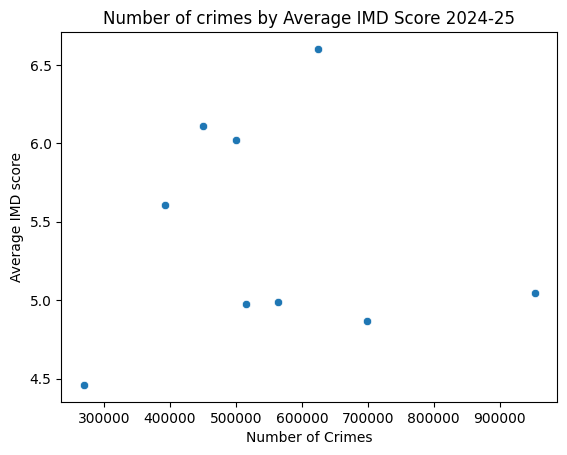

                                            total_offences  avg_imd_by_ITL2  \
ITL2                                                                          
Bedfordshire and Hertfordshire                      134350         6.610619   
Berkshire, Buckinghamshire and Oxfordshire          172209         7.286869   
Cambridgeshire and Peterborough                      67710         6.432171   

                                            avg_imd_rank_by_ITL2  
ITL2                                                              
Bedfordshire and Hertfordshire                      20739.552212  
Berkshire, Buckinghamshire and Oxfordshire          22988.432997  
Cambridgeshire and Peterborough                     20027.490310  


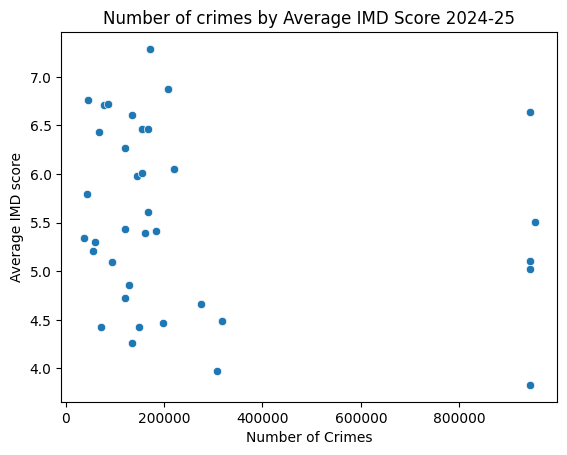

In [23]:
crime_df = pd.read_csv("CLEANED-regional_forces_crime_data_2024-2025.csv")
imd_df = pd.read_csv("clean_index_of_multiple_deprivation.csv")


# Check to see if there are corresponding columns
print(crime_df.columns) 
print(imd_df.columns)

# print(crime_df.info())

crime_df.rename(columns={"ITL1 region": "ITL1", "ITL2 region": "ITL2"}, inplace=True) # The two excel files have different names for the columns so I'm cleaning these to check
# print(imd_df["ITL1"].tail(4))
# print(crime_df["ITL1"].tail(4))


crime_df.loc[crime_df["ITL1"] == "East Midlands", "ITL1"] = "East Midlands (England)" # Making sure the data is uniform in these specific columns
crime_df.loc[crime_df["ITL1"] == "West Midlands", "ITL1"] = "West Midlands (England)"

#ITL1 comparison

ITL1_grouped_crimes = crime_df.groupby("ITL1")["Number of Offences"].sum()
# print(ITL1_grouped_crimes)
number_of_crimes = crime_df.groupby("Offence Group")["Number of Offences"].sum()

avg_imd_by_ITL1 = imd_df.groupby("ITL1")["IMD Decile"].mean() # Finding the average mean for the ITL1 regions IMD scores
avg_imd_by_ITL2 = imd_df.groupby("ITL2")["IMD Decile"].mean() # Finding the average mean for the ITL2 regions IMD scores
avg_imd_rank_by_ITL2 = imd_df.groupby("ITL2")["IMD Rank"].mean()
IMD2_dict = avg_imd_by_ITL2.to_dict()
IMD_dict = avg_imd_by_ITL1.to_dict()
IMD2_rank_dict = avg_imd_rank_by_ITL2.to_dict()


crime_df["IMD_ITL1"] = crime_df["ITL1"].map(IMD_dict)

regional_summary = crime_df.groupby("ITL1").agg(
    total_offences = ("Number of Offences", "sum"),
    avg_imd_by_ITL1 =("IMD_ITL1", "mean"))


sns.scatterplot(x="total_offences", y="avg_imd_by_ITL1", data=regional_summary)
plt.xlabel("Number of Crimes")
plt.ylabel("Average IMD score")
plt.title("Number of crimes by Average IMD Score 2024-25")
plt.show()

#To add:
# Labels per region / a colour legend

plt.tight_layout()

#ITL2 scatter graph
crime_df["ITL2"] = crime_df["ITL2"].apply(lambda x: x.split(";")) # This converts the values into a list so that I can find all of their IMD ratings
# print(crime_df["ITL2"])
individual_ITL2 = crime_df.explode("ITL2")
avg_imd_by_ITL2 = imd_df.groupby("ITL2")["IMD Decile"].mean()
IMD2_dict = avg_imd_by_ITL2.to_dict()
IMD2_rank_dict
individual_ITL2["IMD_ITL2"] = individual_ITL2["ITL2"].map(IMD2_dict)
individual_ITL2["IMD_rank_ITL2"] = individual_ITL2["ITL2"].map(IMD2_rank_dict)

regional_summary = individual_ITL2.groupby("ITL2").agg( # Now I will find the average IMD score per ITL2 region
    total_offences = ("Number of Offences", "sum"),
    avg_imd_by_ITL2 =("IMD_ITL2", "mean"),
    avg_imd_rank_by_ITL2 = ("IMD_rank_ITL2", "mean")
    )
print(regional_summary.head(3)) # testing to see if it has created a good table
regional_summary.to_csv("machine_learning.csv")

sns.scatterplot(x="total_offences", y="avg_imd_by_ITL2",  data=regional_summary)
plt.xlabel("Number of Crimes")
plt.ylabel("Average IMD score")
plt.title("Number of crimes by Average IMD Score 2024-25")
plt.show()

#### Wellness Data X Crime Data

<>:26: SyntaxWarning: invalid escape sequence '\W'
<>:74: SyntaxWarning: invalid escape sequence '\W'
<>:117: SyntaxWarning: invalid escape sequence '\W'
<>:26: SyntaxWarning: invalid escape sequence '\W'
<>:74: SyntaxWarning: invalid escape sequence '\W'
<>:117: SyntaxWarning: invalid escape sequence '\W'
C:\Users\jade_\AppData\Local\Temp\ipykernel_24176\690849602.py:26: SyntaxWarning: invalid escape sequence '\W'
  "old_data\Wellness_Data.xlsx",
C:\Users\jade_\AppData\Local\Temp\ipykernel_24176\690849602.py:74: SyntaxWarning: invalid escape sequence '\W'
  "old_data\Wellness_Data.xlsx",
C:\Users\jade_\AppData\Local\Temp\ipykernel_24176\690849602.py:117: SyntaxWarning: invalid escape sequence '\W'
  "old_data\Wellness_Data.xlsx",


                ITL1 region  Number of Offences                    Region
0            East (England)              450512           East of England
1             East Midlands              392047             East Midlands
2                    London              953103                    London
3      North East (England)              269244                North East
4      North West (England)              698039                North West
5      South East (England)              624439                South East
6      South West (England)              500612                South West
7             West Midlands              515180             West Midlands
8  Yorkshire and The Humber              563303  Yorkshire and The Humber


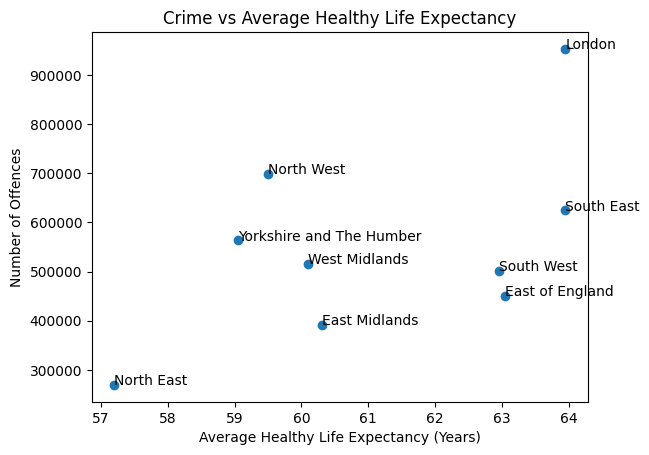

Average life expectancy correlation: 0.543


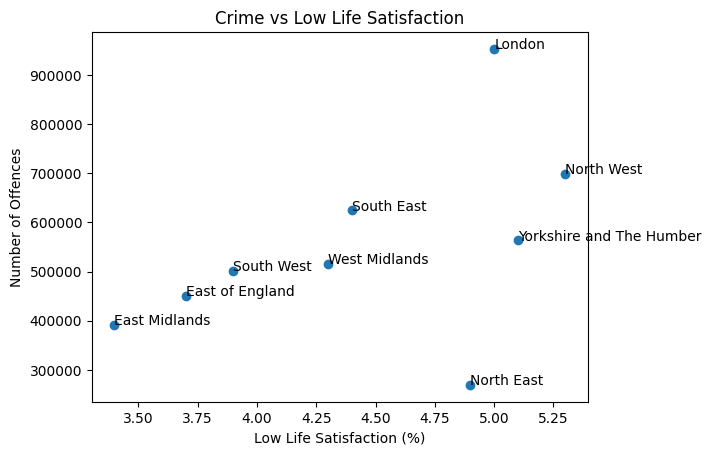

Low life satisfaction correlation: 0.472


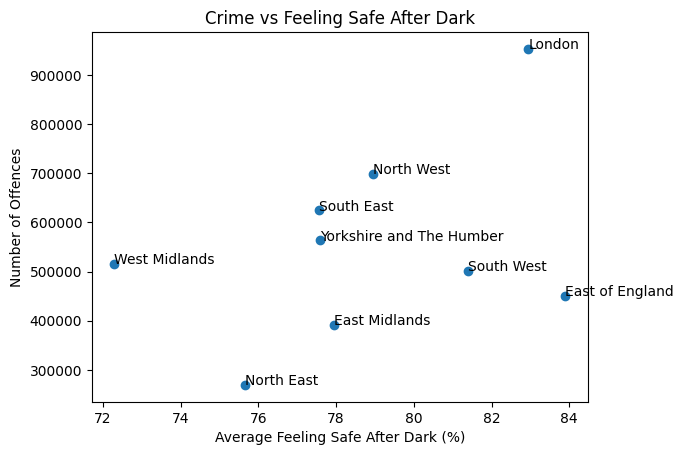

Feeling safe after dark correlation: 0.385


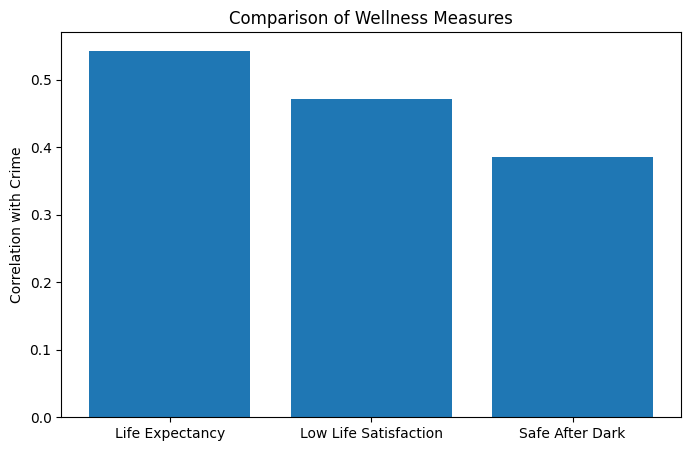

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Crime Data

crime_df = pd.read_csv("CLEANED-regional_forces_crime_data_2024-2025.csv")

crime_by_region_df = (
    crime_df
    .groupby("ITL1 region")["Number of Offences"]
    .sum()
    .reset_index()
)

crime_by_region_df["Region"] = (
    crime_by_region_df["ITL1 region"]
    .str.replace(" \\(England\\)", "", regex=True)
    .replace({"East": "East of England"})
)

print(crime_by_region_df)

# Life Expectancy

life_expectancy_df = pd.read_excel(
    "old_data\Wellness_Data.xlsx",
    sheet_name=5
)


crime_life_expectancy_df = pd.merge(
    crime_by_region_df,
    life_expectancy_df,
    on="Region",
    how="inner"
)

crime_life_expectancy_df["Average_Life_Expectancy"] = (
    crime_life_expectancy_df["Male_Life_Expectancy_Years"] +
    crime_life_expectancy_df["Female_Life_Expectancy_Years"]
) / 2

plt.scatter(
    crime_life_expectancy_df["Average_Life_Expectancy"],
    crime_life_expectancy_df["Number of Offences"]
)

plt.xlabel("Average Healthy Life Expectancy (Years)")
plt.ylabel("Number of Offences")
plt.title("Crime vs Average Healthy Life Expectancy")

for _, row in crime_life_expectancy_df.iterrows():
    plt.annotate(
        row["Region"],
        (
            row["Average_Life_Expectancy"],
            row["Number of Offences"]
        )
    )

plt.show()

life_expectancy_corr = crime_life_expectancy_df[
    "Average_Life_Expectancy"
].corr(
    crime_life_expectancy_df["Number of Offences"]
)

print(f"Average life expectancy correlation: {life_expectancy_corr:.3f}")

# Low Life Satisfaction

life_satisfaction_df = pd.read_excel(
    "old_data\Wellness_Data.xlsx",
    sheet_name=0
)

crime_life_satisfaction_df = pd.merge(
    crime_by_region_df,
    life_satisfaction_df,
    on="Region",
    how="inner"
)

plt.scatter(
    crime_life_satisfaction_df["Low_Life_Satisfaction_Percentage"],
    crime_life_satisfaction_df["Number of Offences"]
)

plt.xlabel("Low Life Satisfaction (%)")
plt.ylabel("Number of Offences")
plt.title("Crime vs Low Life Satisfaction")

for _, row in crime_life_satisfaction_df.iterrows():
    plt.annotate(
        row["Region"],
        (
            row["Low_Life_Satisfaction_Percentage"],
            row["Number of Offences"]
        )
    )

plt.show()

life_satisfaction_corr = crime_life_satisfaction_df[
    "Low_Life_Satisfaction_Percentage"
].corr(
    crime_life_satisfaction_df["Number of Offences"]
)

print(f"Low life satisfaction correlation: {life_satisfaction_corr:.3f}")


# Feeling Safe After Dark

safe_after_dark_df = pd.read_excel(
    "old_data\Wellness_Data.xlsx",
    sheet_name=13
)

safe_after_dark_df["Average_Safe_After_Dark"] = (
    safe_after_dark_df["Males_Who_Feel_Safe_Walking_Local_Area_Alone_After_Dark_Percentage"] +
    safe_after_dark_df["Females_Who_Feel_Safe_Walking_Local_Area_Alone_After_Dark_Percentage"]
) / 2

crime_safe_after_dark_df = pd.merge(
    crime_by_region_df,
    safe_after_dark_df,
    on="Region",
    how="inner"
)

plt.scatter(
    crime_safe_after_dark_df["Average_Safe_After_Dark"],
    crime_safe_after_dark_df["Number of Offences"]
)

plt.xlabel("Average Feeling Safe After Dark (%)")
plt.ylabel("Number of Offences")
plt.title("Crime vs Feeling Safe After Dark")

for _, row in crime_safe_after_dark_df.iterrows():
    plt.annotate(
        row["Region"],
        (
            row["Average_Safe_After_Dark"],
            row["Number of Offences"]
        )
    )

plt.show()

safe_after_dark_corr = crime_safe_after_dark_df[
    "Average_Safe_After_Dark"
].corr(
    crime_safe_after_dark_df["Number of Offences"]
)

print(f"Feeling safe after dark correlation: {safe_after_dark_corr:.3f}")

# Correlation Comparison

measures = [
    "Life Expectancy",
    "Low Life Satisfaction",
    "Safe After Dark"
]

correlations = [
    life_expectancy_corr,
    life_satisfaction_corr,
    safe_after_dark_corr
]

plt.figure(figsize=(8, 5))

plt.bar(
    measures,
    correlations
)

plt.ylabel("Correlation with Crime")
plt.title("Comparison of Wellness Measures")

plt.show()

#### London Crime & Deprivation Analysis 

I found during exploratory data analysis that not only did London report the most offences, but it also had a distinctive crime profile. Of the five most recorded offence subgroups, three were theft related offences - other theft offences, theft from the person and shoplifting. This suggested that theft-related crime may play a particularly important role in explaining crime patterns within London and motivated further investigation alongside deprivation data.

How to interpret the IMD numbers: 

For **IMD Rank, the smaller the number the more deprived an area is**. Based on the data above, **Inner London East is the most deprived** ITL2 region in London, and **Outer London - South is the least deprived** ITL2 region in London. 

The **IMD Decile** categorises more broadly, deciles range from 1-10. **Decile 1** = Most deprived 10% of areas in England and **Decile 10** = Least deprived 10% of areas in England.



In [21]:
crime_df = pd.read_csv("CLEANED-regional_forces_crime_data_2024-2025.csv")

imd_df = pd.read_csv("clean_index_of_multiple_deprivation.csv")

imd_map = pd.read_csv(
    "2025_index_of_multiple_deprivation.csv",
)

london_imd = imd_df[
    imd_df["ITL1"] == "London"
]

london_imd["ITL2"].value_counts() # Before visualising deprivation, the number of observations in each ITL2 region was examined

london_imd_summary = ( # To compare deprivation across London's five ITL2 regions, average IMD rank and IMD decile values were calculated. # To understand deprivation at a broader level, the average IMD decile was calculated for each of London's five ITL2 regions.
    london_imd
    .groupby("ITL2")
    .agg({
        "IMD Rank": "mean",
        "IMD Decile": "mean"
    })
    .reset_index()
)

london_imd_summary 

imd_map_clean = imd_map.rename(columns={ # The IMD dataset and boundary files use different column names for the LSOA identifier (a geographic area used primarily by the Office for National Statistics). The relevant columns were renamed to create a join key and make analysis simpler
    "LSOA code (2021)": "lsoa21cd",
    "Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)": "IMD Rank",
    "Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA": "IMD Decile"
})


imd_map_clean["ITL2"] = imd_df["ITL2"]

shp_files = [
    f for f in os.listdir("LB_shp")
    if f.endswith(".shp")
]

boroughs = []

for shp in shp_files:
    gdf = gpd.read_file(f"LB_shp/{shp}")
    boroughs.append(gdf)

london_boundaries = pd.concat(
    boroughs,
    ignore_index=True
)

london_map = london_boundaries.merge(
    imd_map_clean,
    on="lsoa21cd",
    how="left"
)

itl2_map = ( # To provide an overview of deprivation across London, the average IMD decile was calculated for each of the five ITL2 regions. This allows deprivation patterns to be compared regionally before examining neighbourhood-level variation:
    london_map
    .dissolve(
        by="ITL2",
        aggfunc={
            "IMD Rank": "mean",
            "IMD Decile": "mean"
        }
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 10))

itl2_map.plot(
    column="IMD Decile",
    cmap="viridis",
    legend=True,
    edgecolor="black",
    linewidth=1,
    ax=ax
)

ax.set_title(
    "Average IMD Decile by London ITL2 Region",
    fontsize=16,
    pad=20
)

ax.axis("off")

plt.show()



FileNotFoundError: [WinError 3] The system cannot find the path specified: 'LB_shp'

#### Visualising Deprivation Data Across London in more detail

Although direct comparison between crime and deprivation was not possible, the ITL2 analysis suggested that regional averages may hide important local variation. To investigate this further, deprivation was examined at LSOA level.

At ITL2 level, London appears to exhibit a straightforward deprivation pattern. Inner London - East (dark purple) has the lowest average IMD decile and is therefore the most deprived region on average, while Outer London - South (yellow) has the highest average IMD decile and is the least deprived. However, these averages may mask variation within each region.

To better understand how deprivation varies across London, a geographic visualisation was created. Choropleth maps are particularly useful for displaying regional differences because they allow patterns to be viewed spatially rather than as a simple ranking.

A choropleth map was preferred to a traditional bar chart because IMD Rank is an inverse measure of deprivation, where lower values indicate greater deprivation. While a bar chart could still be used, it may be less intuitive for readers, as taller bars would represent areas with lower levels of deprivation. A map provides a clearer visual representation of how deprivation is distributed across London.

With these findings it is clear that there is significant variation in IMDs across London and to get a more accurate picture of data. The choropleth map highlights substantial variation in deprivation across London. Areas with lower IMD deciles (shown in darker colours) are concentrated in several parts of Inner London, although deprivation is present throughout the capital. Areas with higher IMD deciles (shown in lighter colours) are more common in parts of Outer London. The map demonstrates that deprivation is not evenly distributed across London and varies considerably between neighbourhoods.

In [ ]:
imd_map_clean = imd_map.rename(columns={
    "LSOA code (2021)": "lsoa21cd",
    "Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)": "IMD Rank",
    "Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA": "IMD Decile"
})

london_map = london_boundaries.merge( #The deprivation data was merged with the London boundary data using the LSOA code, creating a dataset suitable for geographic visualisation.
    imd_map_clean,
    on="lsoa21cd",
    how="left"
)

london_map = london_boundaries.merge(
    imd_map_clean,
    on="lsoa21cd",
    how="left"
)

#Chlorepath Map

fig, ax = plt.subplots(figsize=(12, 12))

london_map.plot(
    column="IMD Decile",
    cmap="viridis",
    legend=True,
    linewidth=0,
    ax=ax
)

ax.set_title(
    "Index of Multiple Deprivation (IMD) Across London",
    fontsize=16,
    pad=20
)

ax.axis("off")

plt.show()

## Conclusions and recommendations 

"What your analysis found and what you recommend"